In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
import glob
import tqdm
plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})

In [2]:
label_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/label/BaeklabFinal.Genome.v2Genomic.GP3.depth5_None.twm6astrict.agg.pkl")
label_df.rename(columns = {"m6A_level": "dom_label"}, inplace = True)

In [3]:
print(label_df["label"].value_counts())

label
 0    7491694
-3    5290375
-1     431206
 1      34513
Name: count, dtype: int64


In [47]:
dorado_alt = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/result/reference_test/dorado_output.modkit.bed.m6A.genomic.pkl")
dorado_alt.rename(columns = {"dom": "pred_dorado", "count_dom": "dorado_count"}, inplace = True)
dorado_alt = dorado_alt[["pred_dorado", "dorado_count", "genome_id"]]
print(dorado_alt)

                 pred_dorado  dorado_count        genome_id
genome_id                                                  
chr10:+:1000680     0.285714             7  chr10:+:1000680
chr10:+:1000681     0.008457           473  chr10:+:1000681
chr10:+:1000683     0.002024           494  chr10:+:1000683
chr10:+:1000685     0.017241           464  chr10:+:1000685
chr10:+:1000688     1.000000             1  chr10:+:1000688
...                      ...           ...              ...
chrY:-:5337897      0.000000             1   chrY:-:5337897
chrY:-:5337900      0.000000             1   chrY:-:5337900
chrY:-:5337901      0.000000             1   chrY:-:5337901
chrY:-:5337902      0.000000             1   chrY:-:5337902
chrY:-:5337903      0.000000             1   chrY:-:5337903

[29021832 rows x 3 columns]


In [49]:
m6anet_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/m6anet/ON0090/gene_df.pkl")
m6anet_df.rename(columns = { "pm6a": "pred_m6anet", "dom": "dom_m6anet", "count_pm6a": "count_m6anet"}, inplace = True)
m6anet_df = m6anet_df[["genome_id", "pred_m6anet", "dom_m6anet", "count_m6anet"]]
print(m6anet_df)

                       genome_id  pred_m6anet  dom_m6anet  count_m6anet
genome_id                                                              
chr10:+:1000683  chr10:+:1000683     0.079608    0.014440           277
chr10:+:1000701  chr10:+:1000701     0.237195    0.121673           263
chr10:+:1000722  chr10:+:1000722     0.107223    0.015326           261
chr10:+:1000831  chr10:+:1000831     0.297641    0.111498           287
chr10:+:1000842  chr10:+:1000842     0.131331    0.042146           261
...                          ...          ...         ...           ...
chrY:-:11166816  chrY:-:11166816     0.257612    0.045455            22
chrY:-:11166858  chrY:-:11166858     0.068032    0.000000            20
chrY:-:11166906  chrY:-:11166906     0.604704    0.272727            22
chrY:-:11206471  chrY:-:11206471     0.053661    0.000000            28
chrY:-:11206478  chrY:-:11206478     0.536436    0.333333            27

[311547 rows x 4 columns]


In [50]:
airna_alt = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-m6A_ON0118-20241129-120647-8-182000-token_normalise_ver121224_mergedref_ON0090_m6Afinal/pileup_strid.npz.genomic.pkl"
airna_alt = pd.read_pickle(airna_alt)
print(airna_alt)

                       genome_id      gene_symbol  coding  isoforms      pm6a  \
genome_id                                                                       
chr10:+:1000681  chr10:+:1000681           GTPBP4    True         3 -0.000000   
chr10:+:1000683  chr10:+:1000683           GTPBP4    True         3  0.016154   
chr10:+:1000685  chr10:+:1000685           GTPBP4    True         3 -0.000000   
chr10:+:1000694  chr10:+:1000694           GTPBP4    True         3 -0.000000   
chr10:+:1000701  chr10:+:1000701           GTPBP4    True         3  0.023575   
...                          ...              ...     ...       ...       ...   
chrY:-:5337886    chrY:-:5337886  ENSG00000235001   False         1  0.000000   
chrY:-:5337887    chrY:-:5337887  ENSG00000235001   False         1  0.000000   
chrY:-:5337889    chrY:-:5337889  ENSG00000235001   False         1  0.000000   
chrY:-:5337897    chrY:-:5337897  ENSG00000235001   False         1  0.000000   
chrY:-:5337900    chrY:-:533

In [51]:
airna_alt.reset_index(inplace=True, drop=True)
dorado_alt.reset_index(inplace=True, drop=True)
m6anet_df.reset_index(inplace=True, drop=True)


In [52]:
airna_alt_d20 = airna_alt[airna_alt["count_all"] >= 20]
dorado_alt_d20 = dorado_alt[dorado_alt["dorado_count"] >= 20]
m6anet_df_d20 = m6anet_df[m6anet_df["count_m6anet"] >= 20]

In [53]:
logsum_alt = airna_alt_d20.merge(dorado_alt_d20, on="genome_id", how="outer")
logsum_alt = logsum_alt.merge(m6anet_df_d20, on="genome_id", how="outer")
print(logsum_alt)

                 genome_id gene_symbol coding  isoforms      pm6a       dom  \
0          chr10:+:1000681      GTPBP4   True       3.0 -0.000000  0.004642   
1          chr10:+:1000683      GTPBP4   True       3.0  0.016154  0.013023   
2          chr10:+:1000685      GTPBP4   True       3.0 -0.000000  0.007298   
3          chr10:+:1000694      GTPBP4   True       3.0 -0.000000  0.006251   
4          chr10:+:1000701      GTPBP4   True       3.0  0.023575  0.007125   
...                    ...         ...    ...       ...       ...       ...   
11571597  chrX:+:126472735         NaN    NaN       NaN       NaN       NaN   
11571598  chrX:+:151176601         NaN    NaN       NaN       NaN       NaN   
11571599   chrX:+:53168976         NaN    NaN       NaN       NaN       NaN   
11571600  chrX:-:154484548         NaN    NaN       NaN       NaN       NaN   
11571601   chrX:-:77674626         NaN    NaN       NaN       NaN       NaN   

          count_all  logsum_1_p_pos  kl_div_pos  kl

In [54]:
logsum_alt = logsum_alt[[ "genome_id", "pm6a", "dom", "count_all", "pred_dorado", "dorado_count","pred_m6anet", "dom_m6anet"]].copy()
logsum_alt = logsum_alt.merge(label_df, on="genome_id", how="right")
logsum_alt = logsum_alt.fillna(0)
print(logsum_alt)

                genome_id      pm6a       dom  count_all  pred_dorado  \
0         chr10:+:1000681 -0.000000  0.004642      495.0     0.008457   
1         chr10:+:1000683  0.016154  0.013023      501.0     0.002024   
2         chr10:+:1000685 -0.000000  0.007298      501.0     0.017241   
3         chr10:+:1000694 -0.000000  0.006251      509.0     0.006061   
4         chr10:+:1000701  0.023575  0.007125      498.0     0.002083   
...                   ...       ...       ...        ...          ...   
13247783   chrX:-:9760794  0.000000  0.000000        0.0     0.000000   
13247784   chrX:-:9760797  0.000000  0.000000        0.0     0.000000   
13247785   chrX:-:9760808  0.000000  0.000000        0.0     0.000000   
13247786   chrX:-:9760817  0.000000  0.000000        0.0     0.000000   
13247787   chrX:-:9760823  0.000000  0.000000        0.0     0.000000   

          dorado_count  pred_m6anet  dom_m6anet  drach  dom_label  label  \
0                473.0     0.000000    0.000000

In [55]:
from sklearn.metrics import precision_recall_curve, auc, roc_curve

plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 28, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 10})
plt.rcParams.update({"axes.prop_cycle": plt.cycler("color", ["royalblue", "tomato", "forestgreen", "darkgoldenrod", "darkorchid"])})

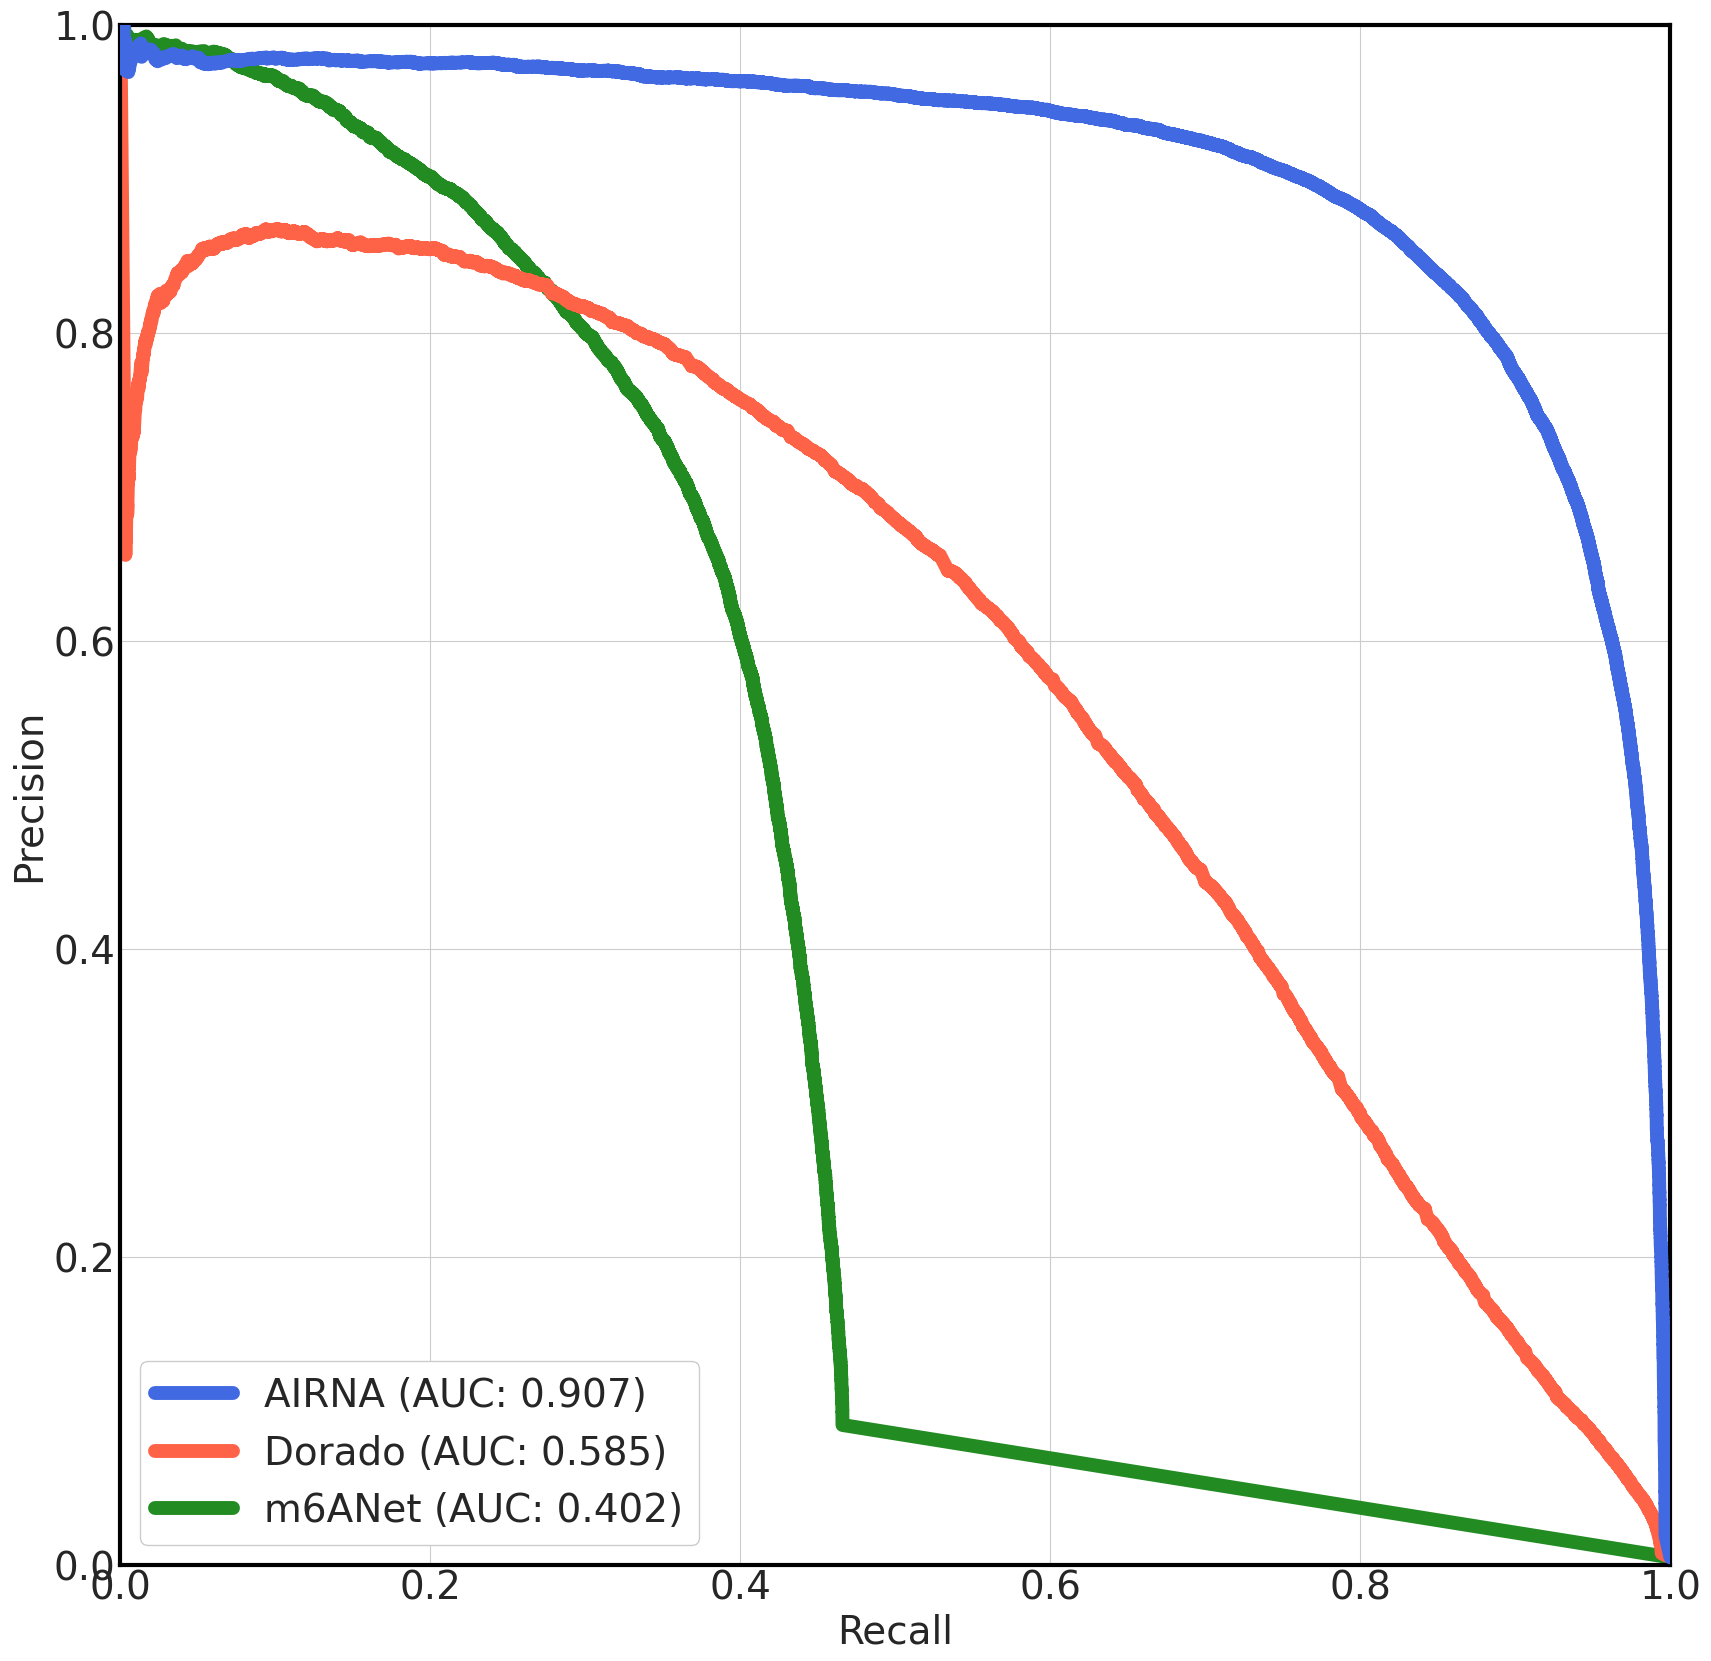

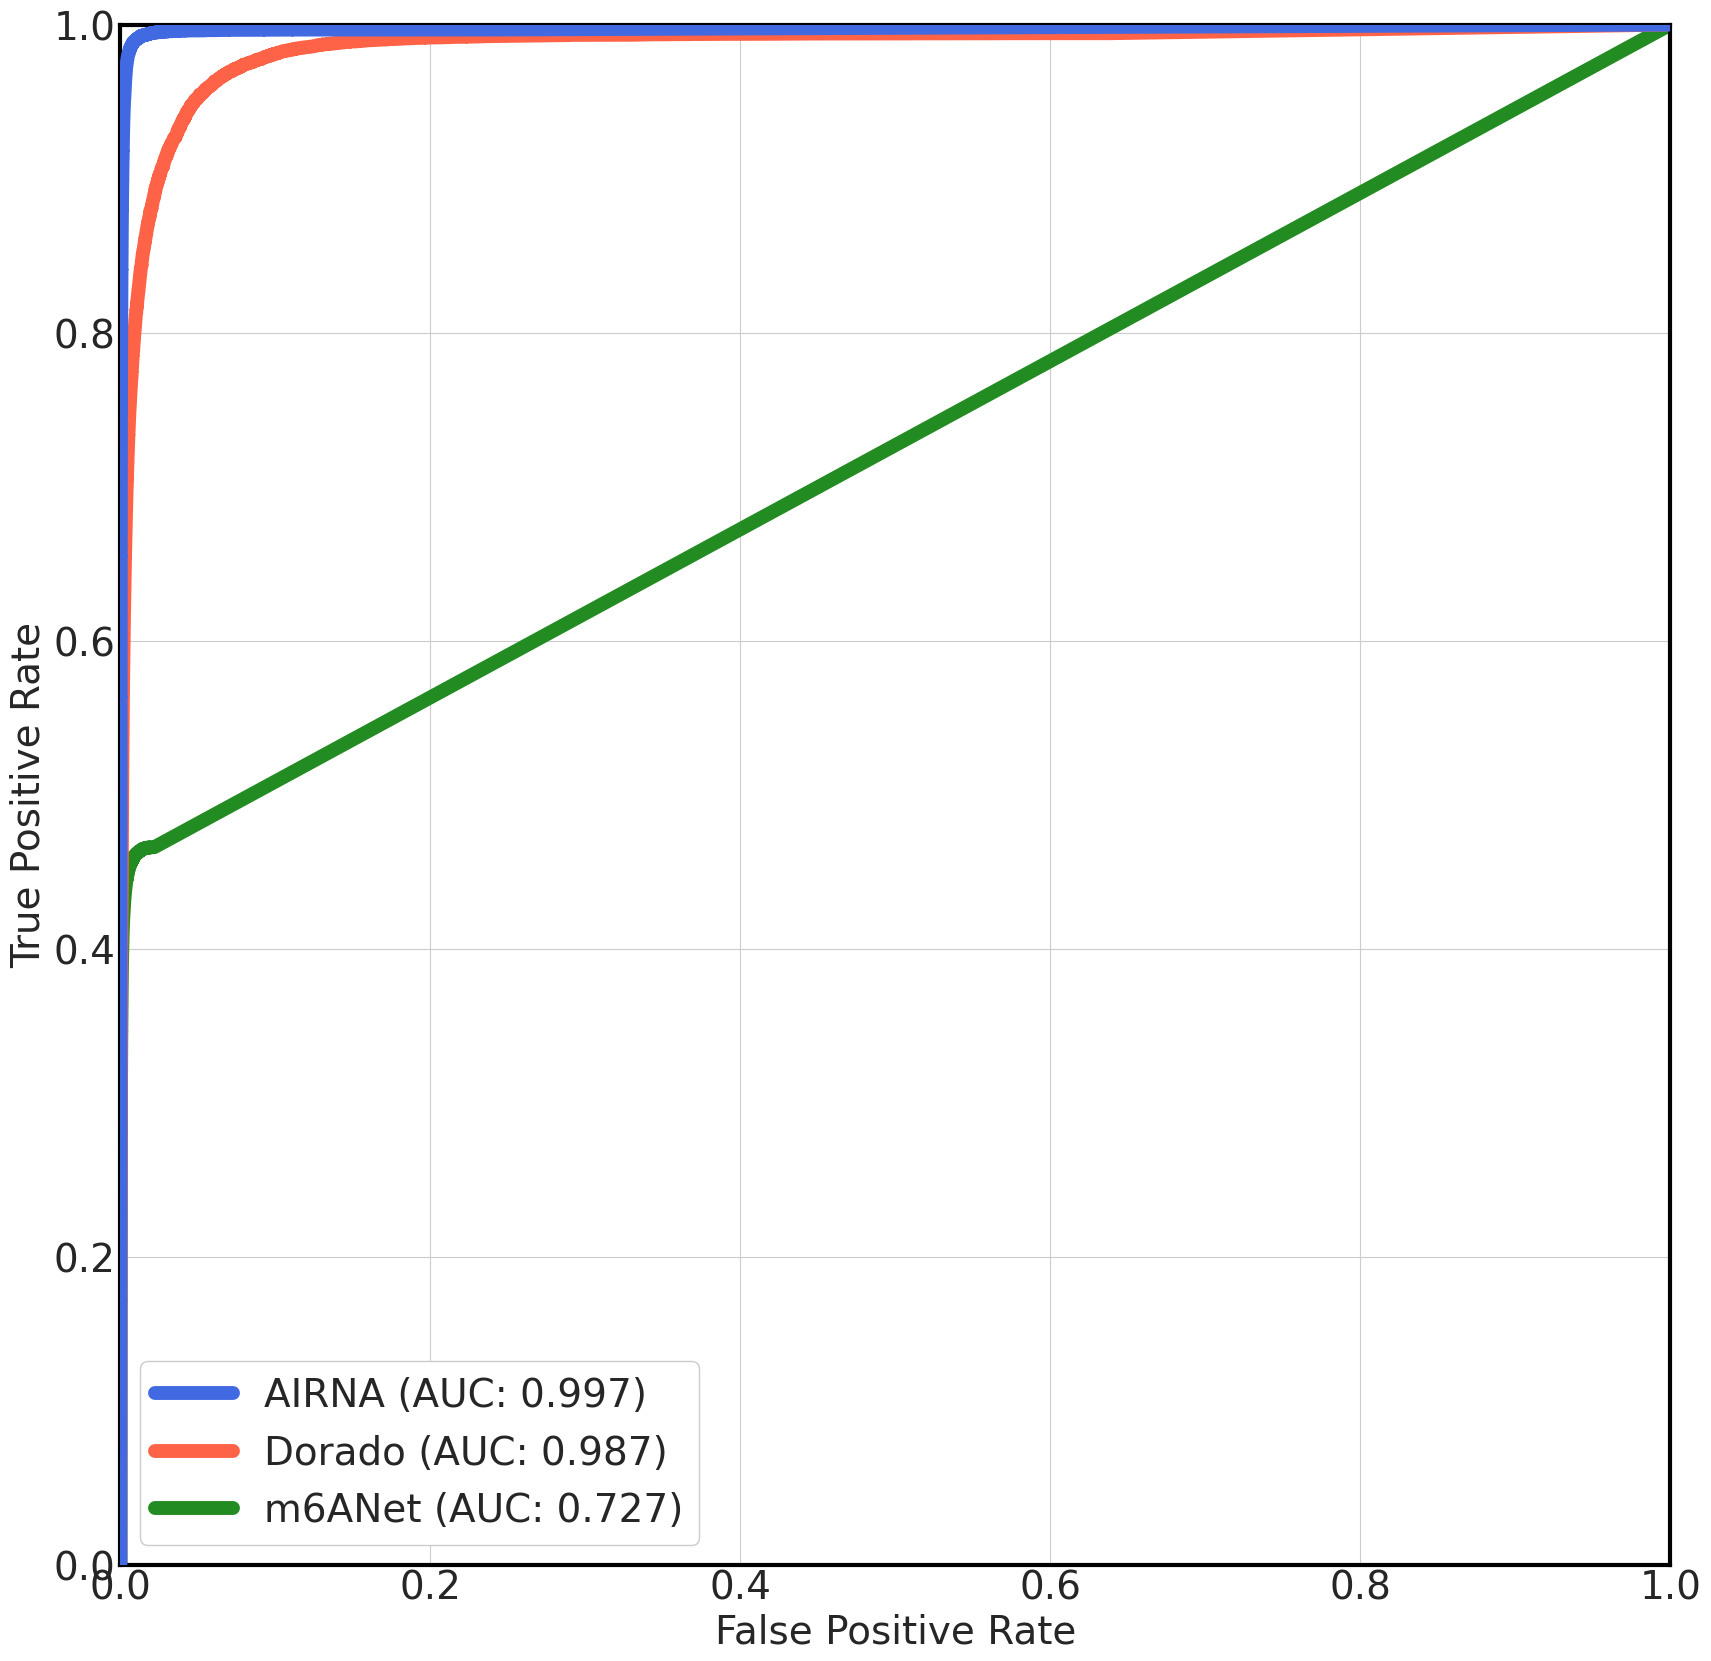

In [56]:

selected_df = logsum_alt[(logsum_alt["label"] >= 0) & (logsum_alt["depth"] >= 20)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df.fillna(0, inplace=True)

## Plot PR
fig, ax = plt.subplots(1, 1, figsize=(20, 20))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA (AUC: {auc_score:.3f})", zorder=3)

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pred_dorado"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Dorado (AUC: {auc_score:.3f})", zorder=2)

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pred_m6anet"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"m6ANet (AUC: {auc_score:.3f})", zorder=1)

## Bolder grid outline
for dir in ["top", "right", "left", "bottom"]:
    ax.spines[dir].set_linewidth(3)
    ax.spines[dir].set_color("black")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.legend()
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/allcontext_pr.pdf", format="pdf")
plt.show()


## Plot ROC
fig, ax = plt.subplots(1, 1, figsize=(20, 20))

fpr, tpr, _ = roc_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(fpr, tpr)
ax.plot(fpr, tpr, label=f"AIRNA (AUC: {auc_score:.3f})", zorder=3)

fpr, tpr, _ = roc_curve(selected_df["label"], selected_df["pred_dorado"])
auc_score = auc(fpr, tpr)
ax.plot(fpr, tpr, label=f"Dorado (AUC: {auc_score:.3f})", zorder=2)

fpr, tpr, _ = roc_curve(selected_df["label"], selected_df["pred_m6anet"])
auc_score = auc(fpr, tpr)
ax.plot(fpr, tpr, label=f"m6ANet (AUC: {auc_score:.3f})", zorder=1)

## Bolder grid outline
for dir in ["top", "right", "left", "bottom"]:
    ax.spines[dir].set_linewidth(3)
    ax.spines[dir].set_color("black")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.legend()
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/allcontext_roc.pdf", format="pdf")
plt.show()


In [57]:

selected_df = logsum_alt[(logsum_alt["label"] >= 0) & (logsum_alt["depth"] >= 20)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
print(selected_df)

                genome_id      pm6a       dom  count_all  pred_dorado  \
0         chr10:+:1000681 -0.000000  0.004642      495.0     0.008457   
1         chr10:+:1000683  0.016154  0.013023      501.0     0.002024   
2         chr10:+:1000685 -0.000000  0.007298      501.0     0.017241   
4         chr10:+:1000701  0.023575  0.007125      498.0     0.002083   
5         chr10:+:1000704  0.024072  0.017848      504.0     0.047312   
...                   ...       ...       ...        ...          ...   
13247521  chrX:-:86047490  0.000000  0.000000       21.0     0.000000   
13247523  chrX:-:86047493  0.000000  0.000000       23.0     0.000000   
13247524  chrX:-:86047498  0.000000  0.000000       23.0     0.000000   
13247526  chrX:-:86047509  0.000000  0.000000       22.0     0.000000   
13247527  chrX:-:86047522  0.000000  0.000000        0.0     0.000000   

          dorado_count  pred_m6anet  dom_m6anet  drach  dom_label  label  \
0                473.0     0.000000    0.000000

                genome_id      pm6a       dom  count_all  pred_dorado  \
0         chr10:+:1000681 -0.000000  0.004642      495.0     0.008457   
2         chr10:+:1000685 -0.000000  0.007298      501.0     0.017241   
5         chr10:+:1000704  0.024072  0.017848      504.0     0.047312   
6         chr10:+:1000713 -0.000000  0.001570      505.0     0.006085   
7         chr10:+:1000716 -0.000000  0.000625      507.0     0.000000   
...                   ...       ...       ...        ...          ...   
13231569  chrX:-:77574324 -0.000000  0.003218      102.0     0.139535   
13231570  chrX:-:77574327 -0.000000  0.001752      103.0     0.000000   
13231572  chrX:-:77574334 -0.000000  0.002262      101.0     0.000000   
13231574  chrX:-:77574337 -0.000000  0.000045      103.0     0.032258   
13231575  chrX:-:77574338 -0.000000  0.009680      103.0     0.010989   

          dorado_count  pred_m6anet  dom_m6anet  drach  dom_label  label  \
0                473.0          0.0         0.0

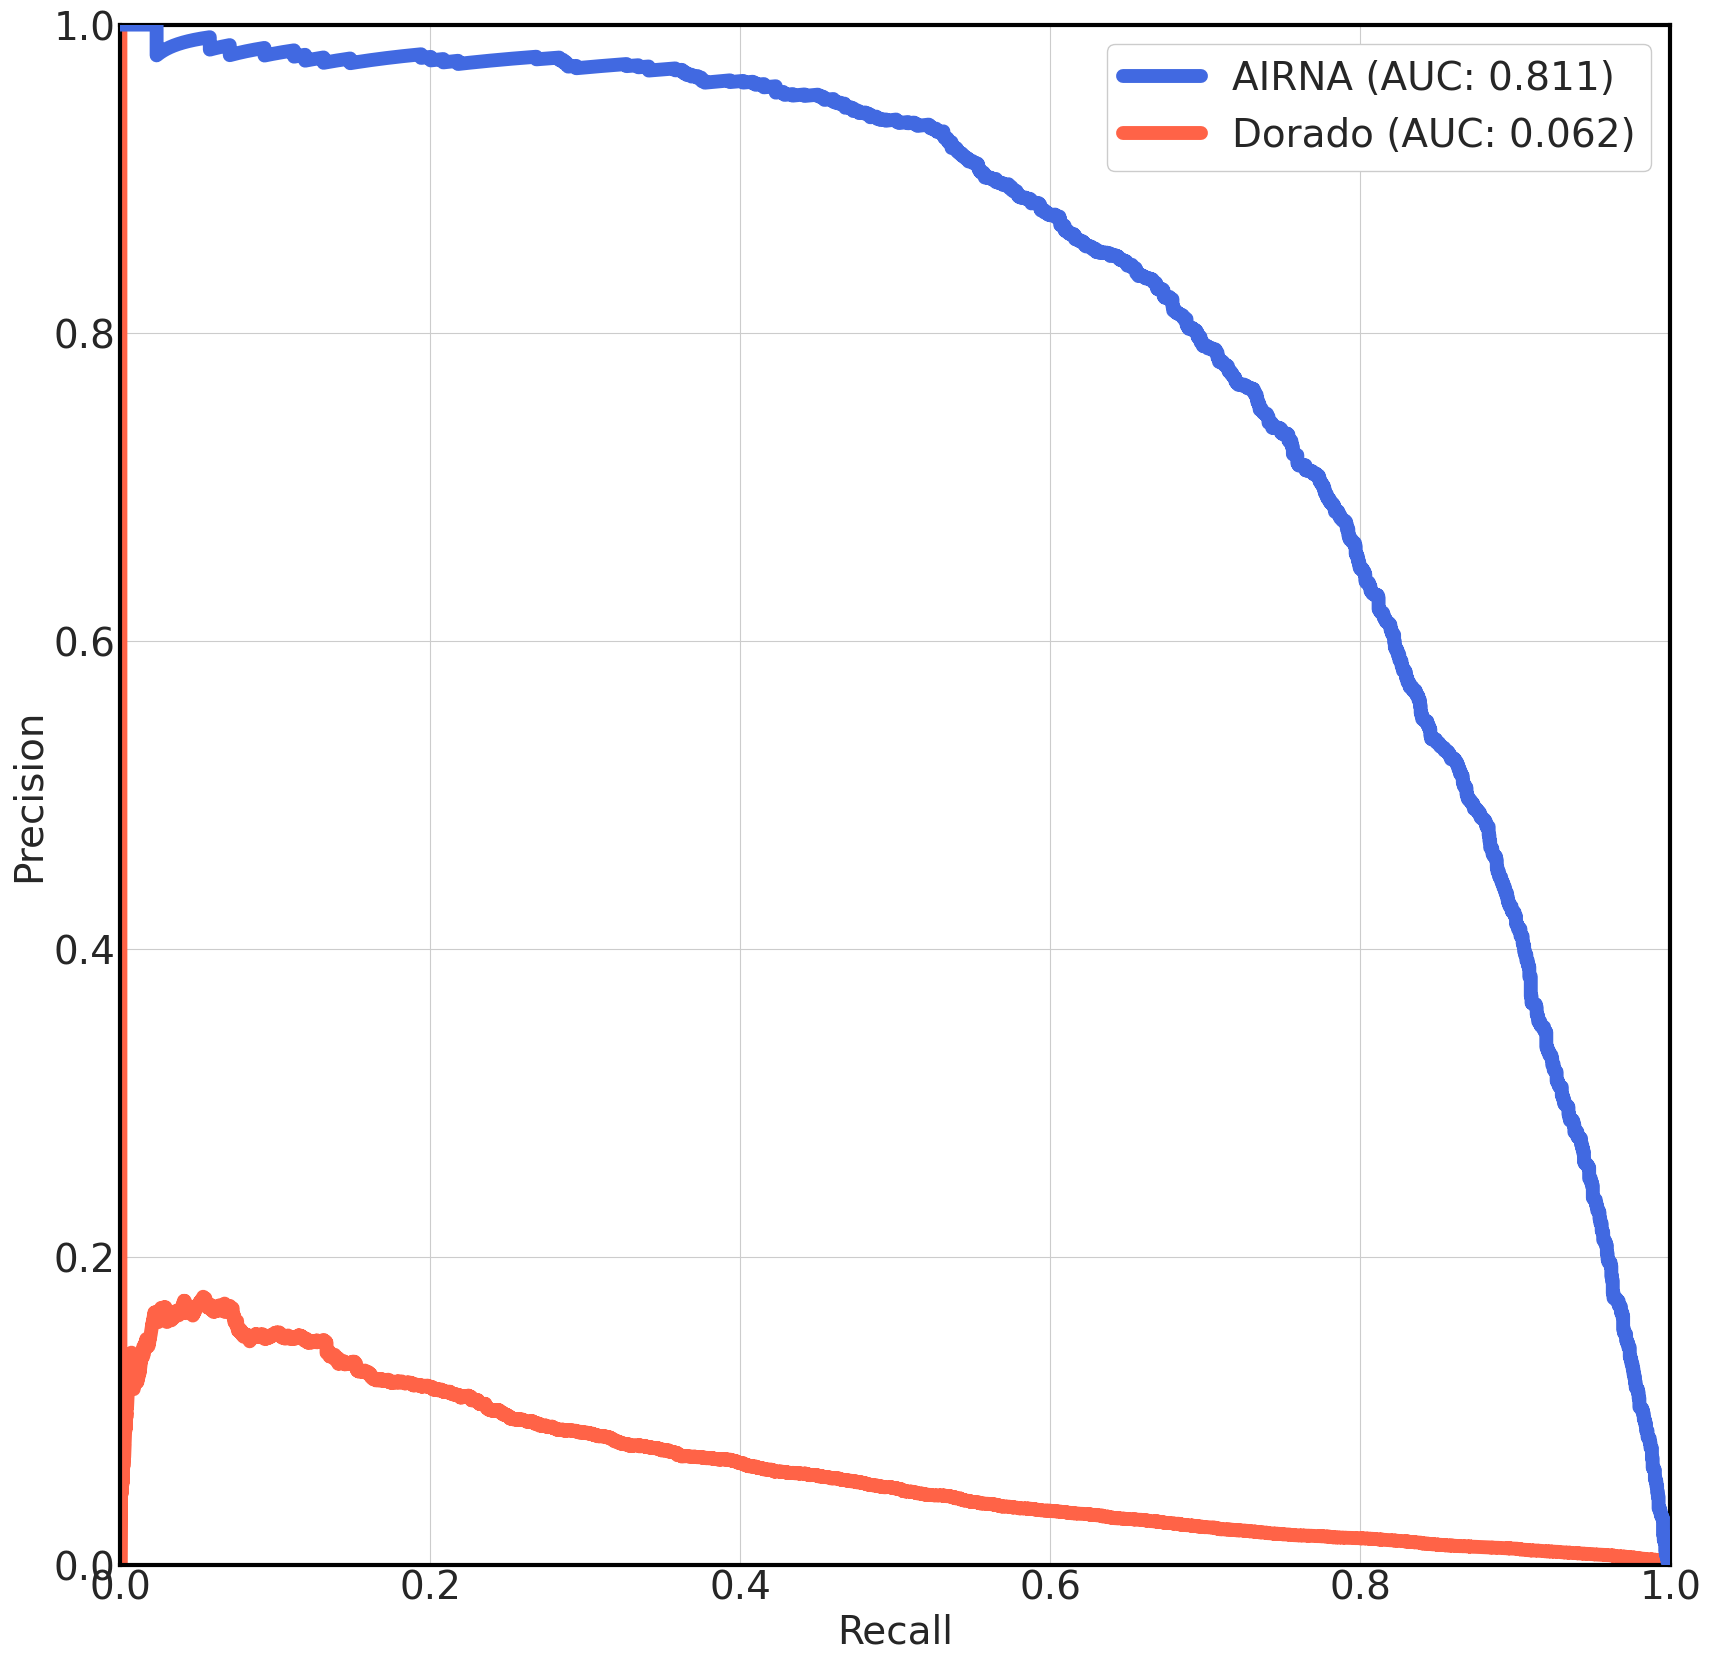

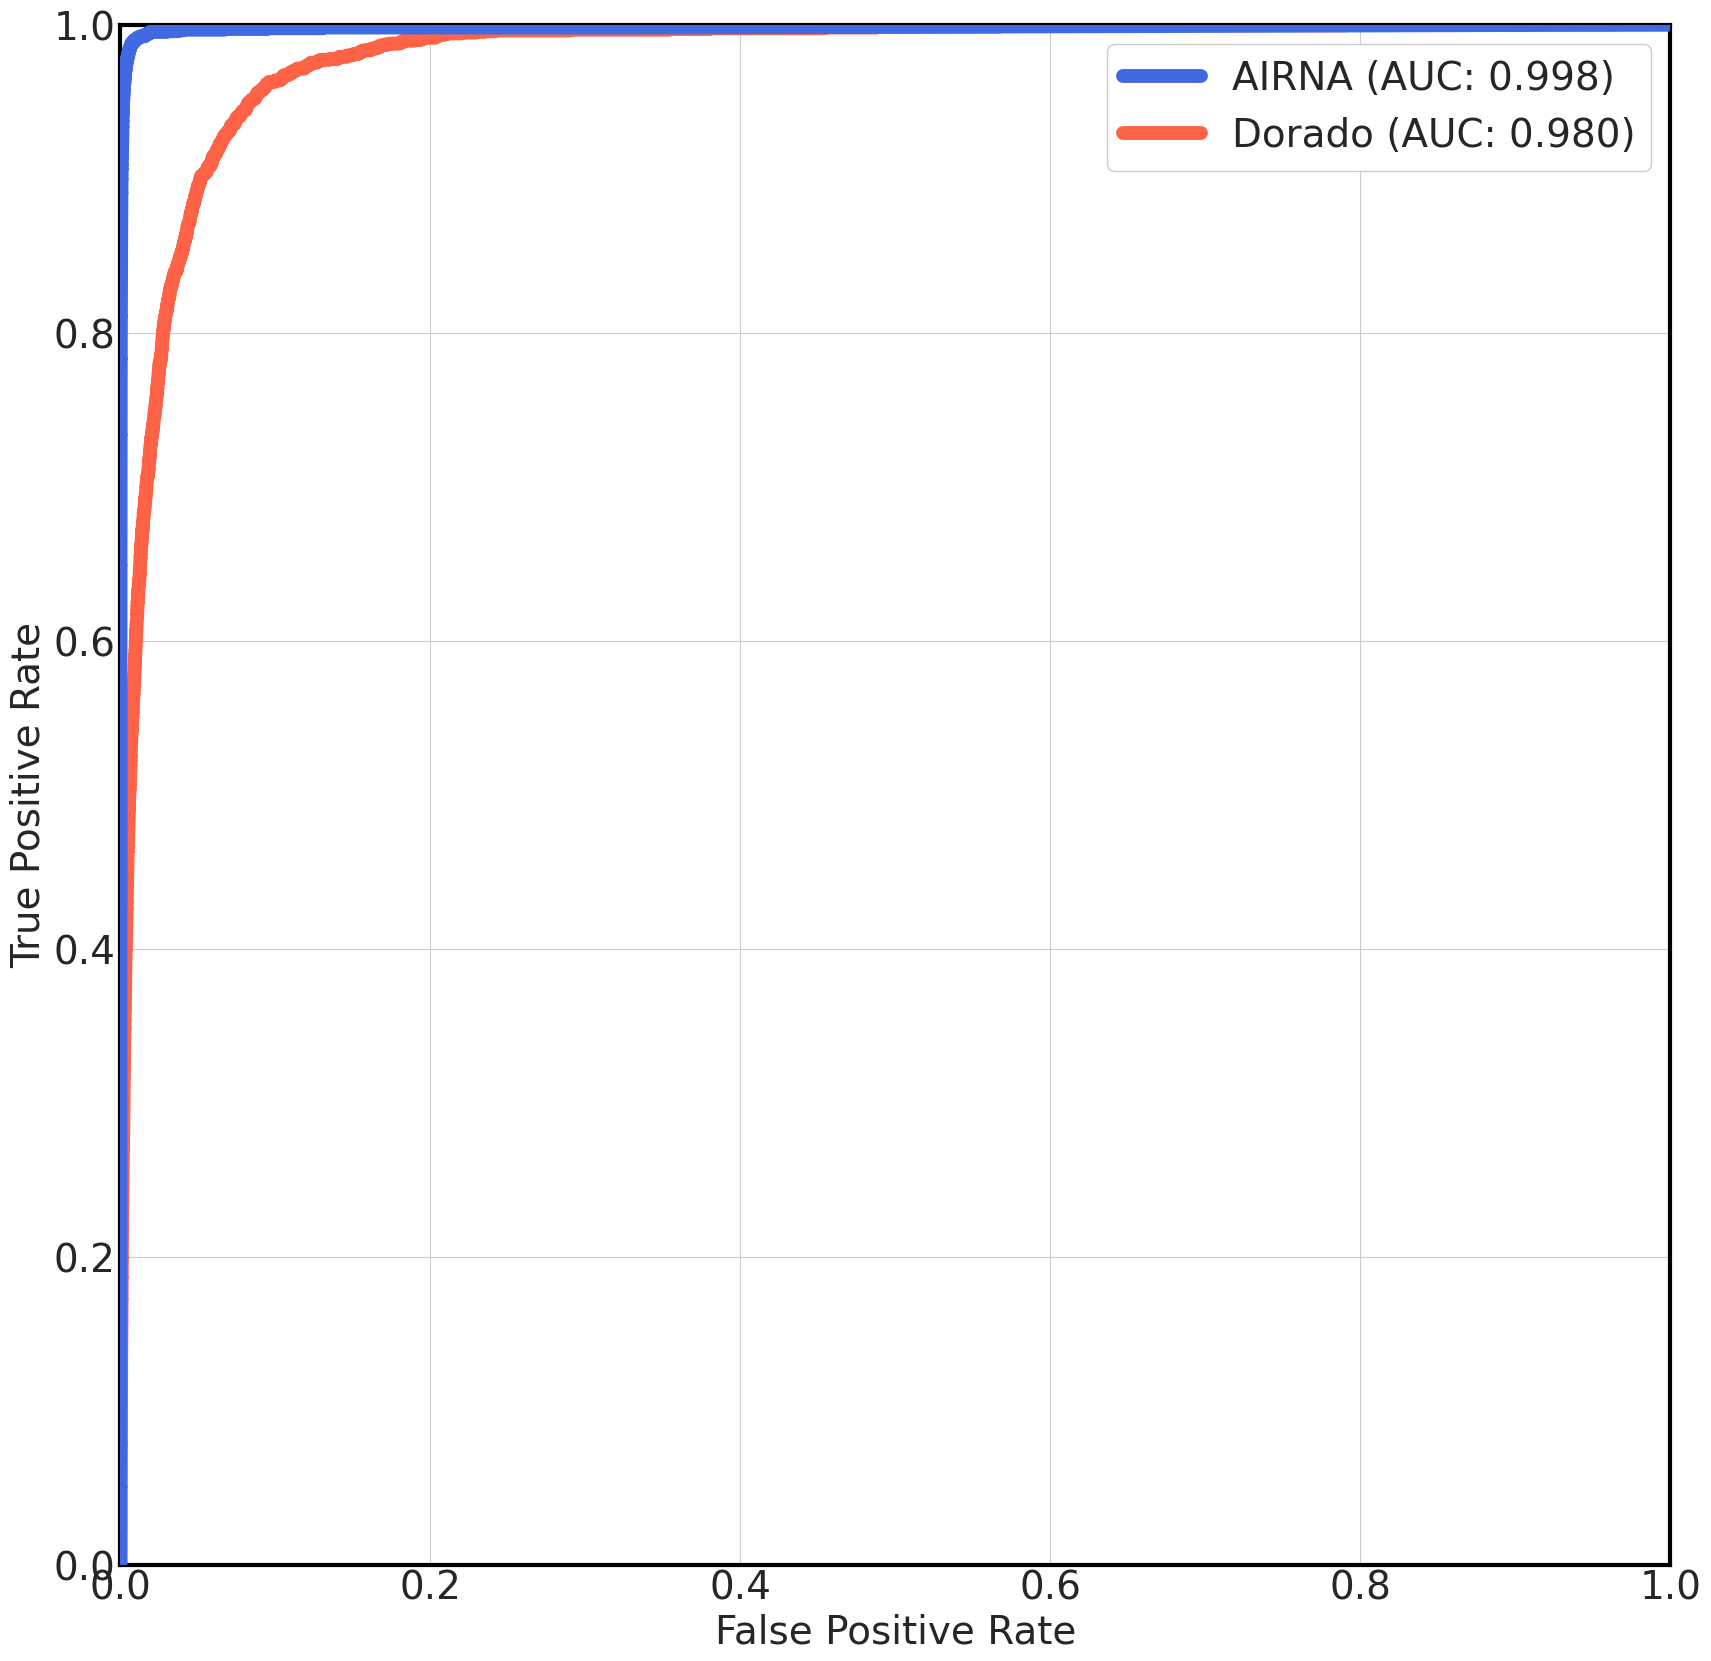

In [58]:
fig, ax = plt.subplots(1, 1, figsize=(20, 20))

selected_df = logsum_alt[~(logsum_alt["drach"]) & ((logsum_alt["depth"] >= 100)) & (logsum_alt["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df.fillna(0, inplace=True)

print(selected_df)

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA (AUC: {auc_score:.3f})", zorder=3)

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pred_dorado"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Dorado (AUC: {auc_score:.3f})", zorder=2)

## Bolder grid outline
for dir in ["top", "right", "left", "bottom"]:
    ax.spines[dir].set_linewidth(3)
    ax.spines[dir].set_color("black")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.legend()
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/nondrach_pr.pdf", format="pdf")
plt.show()


## Plot ROC
fig, ax = plt.subplots(1, 1, figsize=(20, 20))

fpr, tpr, _ = roc_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(fpr, tpr)
ax.plot(fpr, tpr, label=f"AIRNA (AUC: {auc_score:.3f})", zorder=3)

fpr, tpr, _ = roc_curve(selected_df["label"], selected_df["pred_dorado"])
auc_score = auc(fpr, tpr)
ax.plot(fpr, tpr, label=f"Dorado (AUC: {auc_score:.3f})", zorder=2)


## Bolder grid outline
for dir in ["top", "right", "left", "bottom"]:
    ax.spines[dir].set_linewidth(3)
    ax.spines[dir].set_color("black")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.legend()
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/nondrach_roc.pdf", format="pdf")
plt.show()

                genome_id      pm6a       dom  count_all  pred_dorado  \
1         chr10:+:1000683  0.016154  0.013023      501.0     0.002024   
4         chr10:+:1000701  0.023575  0.007125      498.0     0.002083   
10        chr10:+:1000722  0.029512  0.007917      505.0     0.012346   
30        chr10:+:1000831  0.046301  0.021875      511.0     0.018367   
33        chr10:+:1000842  0.017594  0.014126      503.0     0.008734   
...                   ...       ...       ...        ...          ...   
13247474  chrX:-:85978868  0.150818  0.042955       25.0     0.000000   
13247478  chrX:-:85978880 -0.000000  0.003644       25.0     0.040000   
13247480  chrX:-:85978886  0.000000  0.000000       24.0     0.000000   
13247492  chrX:-:85981763 -0.000000  0.000586       24.0     0.000000   
13247496  chrX:-:85981788  0.000000  0.000000       26.0     0.000000   

          dorado_count  pred_m6anet  dom_m6anet  drach  dom_label  label  \
1                494.0     0.079608    0.014440

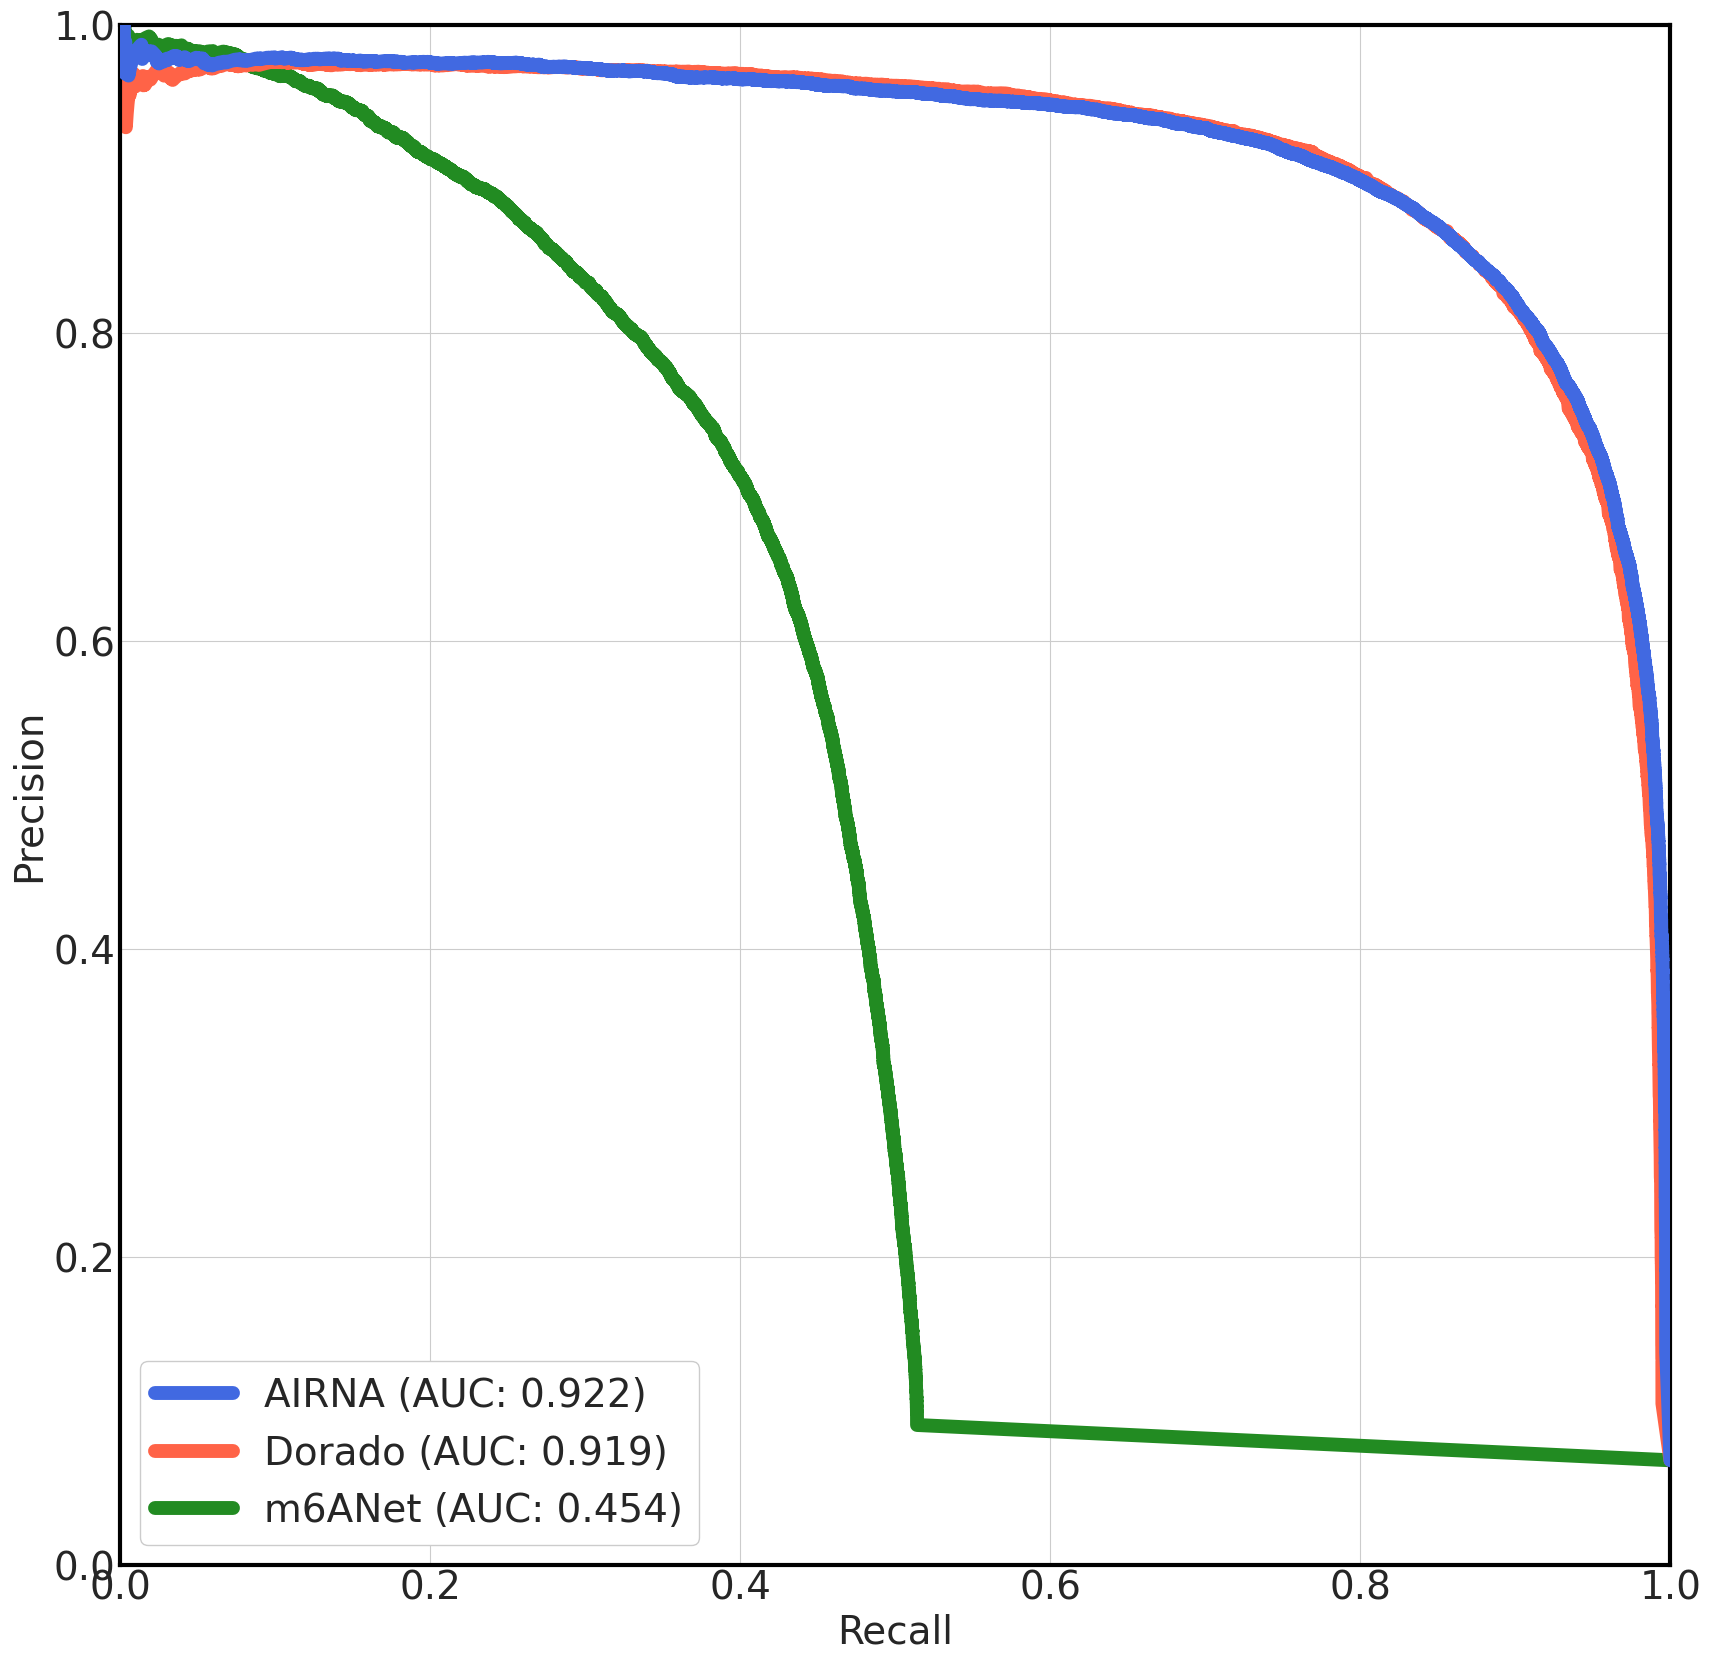

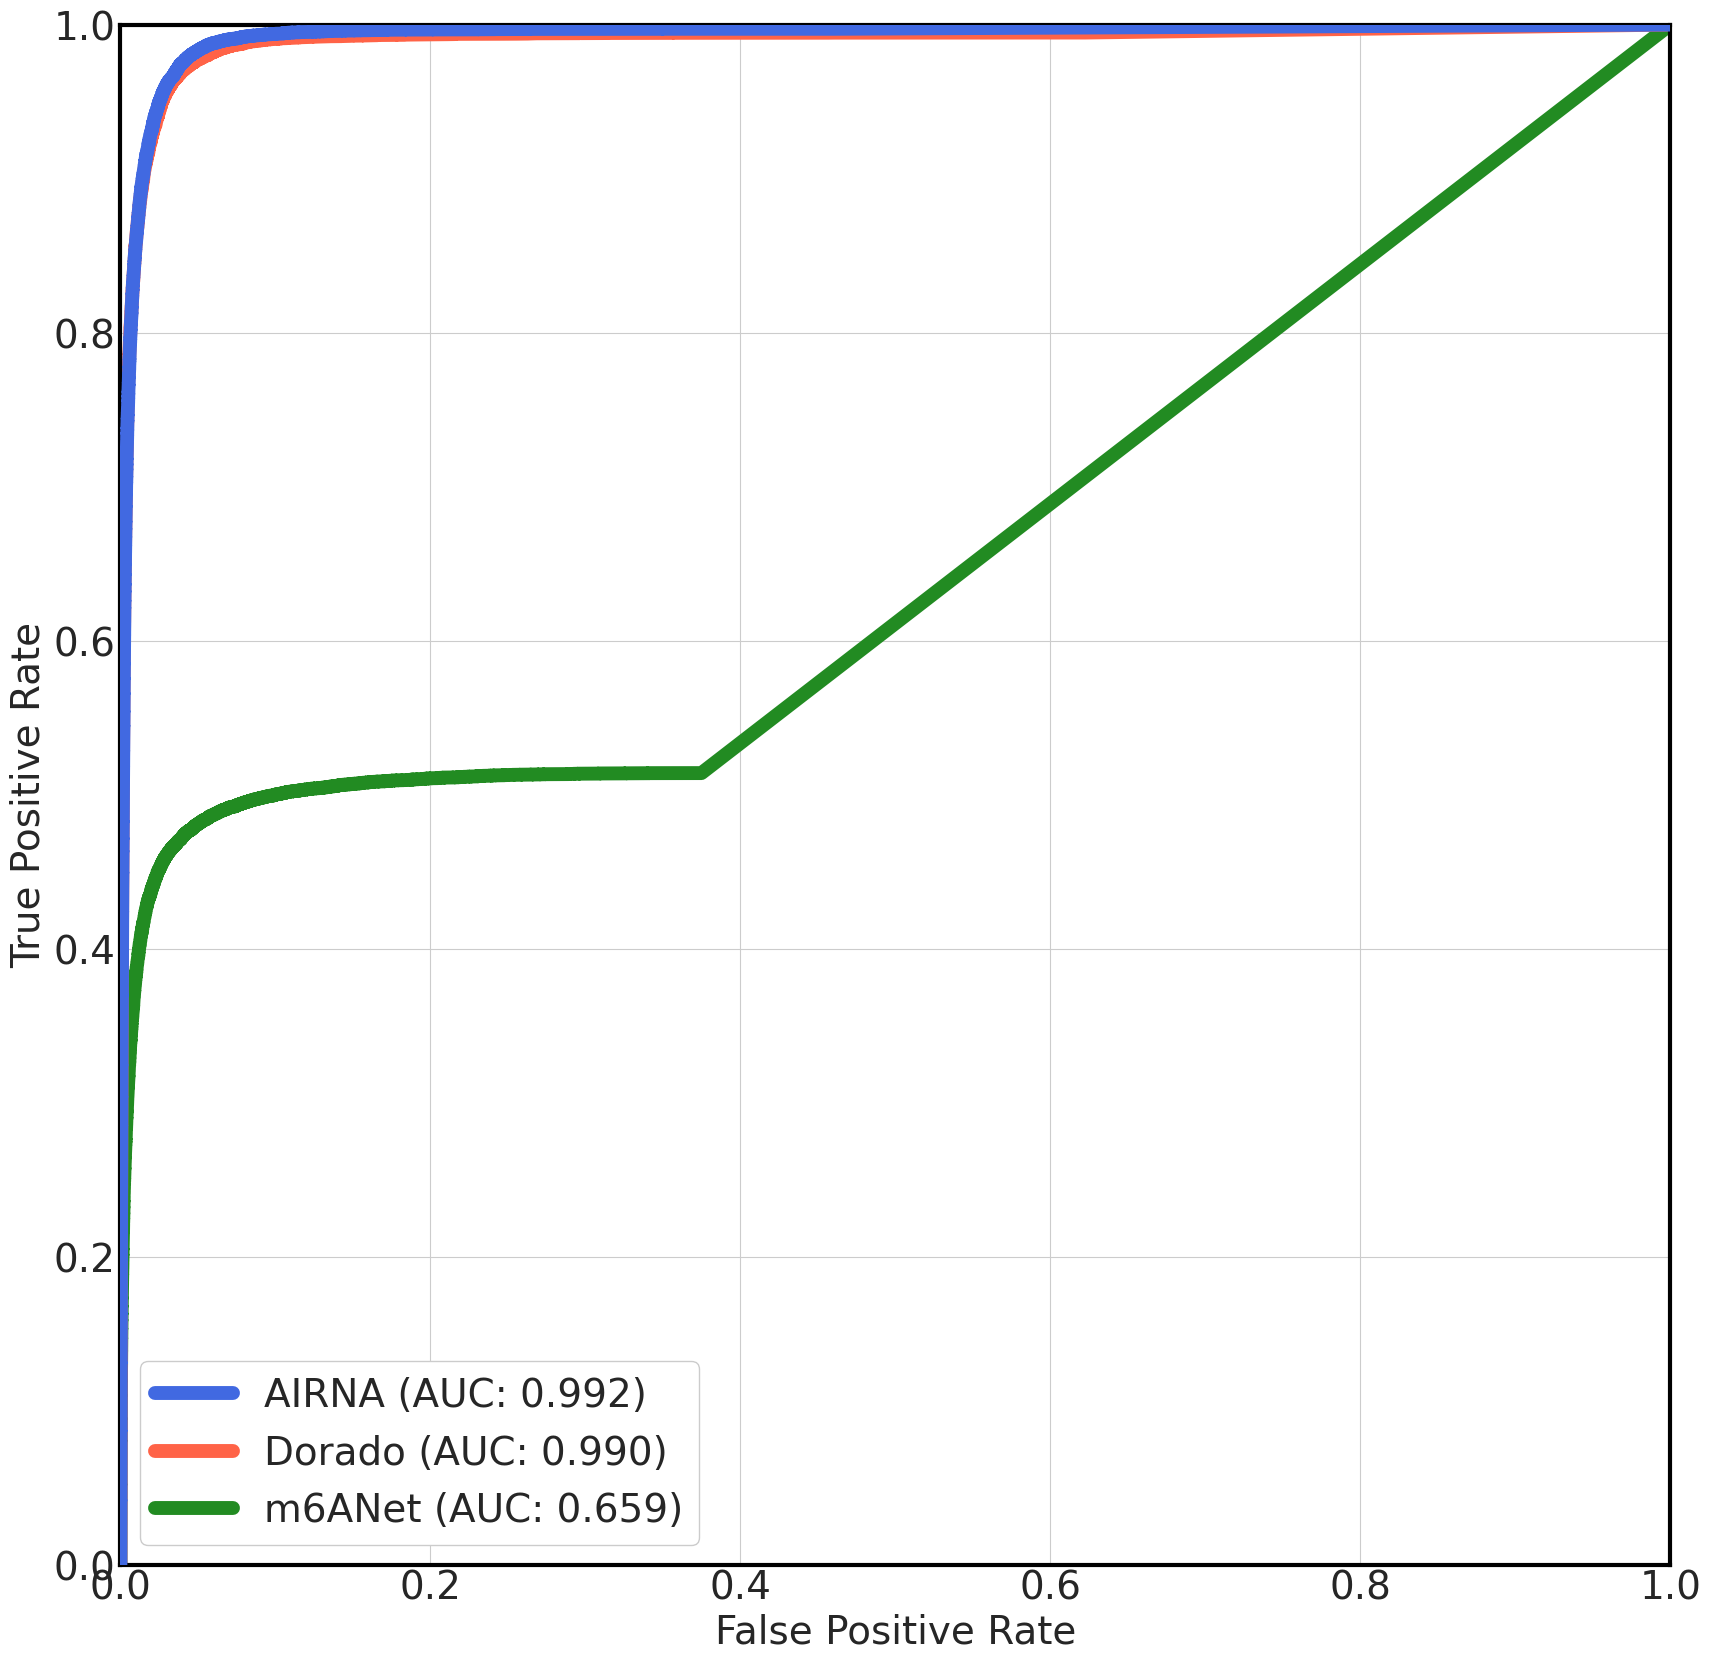

In [59]:
fig, ax = plt.subplots(1, 1, figsize=(20, 20))

selected_df = logsum_alt[(logsum_alt["drach"]) & (logsum_alt["label"] >= 0)& (logsum_alt["depth"] >= 20)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df.fillna(0, inplace=True)

print(selected_df)

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA (AUC: {auc_score:.3f})", zorder=3)

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pred_dorado"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Dorado (AUC: {auc_score:.3f})", zorder=2)

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pred_m6anet"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"m6ANet (AUC: {auc_score:.3f})", zorder=1)

## Bolder grid outline
for dir in ["top", "right", "left", "bottom"]:
    ax.spines[dir].set_linewidth(3)
    ax.spines[dir].set_color("black")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.legend()
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/drach_pr.pdf", format="pdf")
plt.show()


## Plot ROC
fig, ax = plt.subplots(1, 1, figsize=(20, 20))

fpr, tpr, _ = roc_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(fpr, tpr)
ax.plot(fpr, tpr, label=f"AIRNA (AUC: {auc_score:.3f})", zorder=3)

fpr, tpr, _ = roc_curve(selected_df["label"], selected_df["pred_dorado"])
auc_score = auc(fpr, tpr)
ax.plot(fpr, tpr, label=f"Dorado (AUC: {auc_score:.3f})", zorder=2)

fpr, tpr, _ = roc_curve(selected_df["label"], selected_df["pred_m6anet"])
auc_score = auc(fpr, tpr)
ax.plot(fpr, tpr, label=f"m6ANet (AUC: {auc_score:.3f})", zorder=1)

## Bolder grid outline
for dir in ["top", "right", "left", "bottom"]:
    ax.spines[dir].set_linewidth(3)
    ax.spines[dir].set_color("black")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.legend()
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/drach_roc.pdf", format="pdf")
plt.show()


In [60]:

selected_df = logsum_alt[(logsum_alt["label"] >= 0) & (logsum_alt["depth"] >= 20)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df.fillna(0, inplace=True)

precision, recall, thresholds = precision_recall_curve(selected_df["label"], selected_df["pm6a"])
f1 = 2 * (precision * recall) / (precision + recall)

f1_argmax = np.argmax(f1)
max_f1 = f1[f1_argmax]
threshold = thresholds[f1_argmax]

print(f"AIRNA Max F1: {max_f1:.3f}, Threshold: {threshold:.3f}")


precision, recall, thresholds = precision_recall_curve(selected_df["label"], selected_df["pred_dorado"])
f1 = 2 * (precision * recall) / (precision + recall)

f1_argmax = np.argmax(f1)
max_f1 = f1[f1_argmax]
m6anet_threshold = thresholds[f1_argmax]

print(f"Dorado Max F1: {max_f1:.3f}, Threshold: {m6anet_threshold:.3f}")

precision, recall, thresholds = precision_recall_curve(selected_df["label"], selected_df["pred_m6anet"])
f1 = 2 * (precision * recall) / (precision + recall)

f1_argmax = np.argmax(f1)
max_f1 = f1[f1_argmax]
m6anet_threshold = thresholds[f1_argmax]

print(f"m6Anet Max F1: {max_f1:.3f}, Threshold: {m6anet_threshold:.3f}")

AIRNA Max F1: 0.844, Threshold: 0.841
Dorado Max F1: 0.590, Threshold: 0.458
m6Anet Max F1: 0.485, Threshold: 0.551


In [61]:

selected_df = logsum_alt[(logsum_alt["label"] >= 0) & (logsum_alt["depth"] >= 20)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df.fillna(0, inplace=True)

precision, recall, thresholds = precision_recall_curve(selected_df["label"], selected_df["pm6a"])
f1 = 2 * (precision * recall) / (precision + recall)

f1_argmax = np.argmax(f1)
max_f1 = f1[f1_argmax]
threshold = thresholds[f1_argmax]

print(f"AIRNA Max F1: {max_f1:.3f}, Threshold: {threshold:.3f}, Recall: {recall[f1_argmax]:.3f}, Precision: {precision[f1_argmax]:.3f}")


precision, recall, thresholds = precision_recall_curve(selected_df["label"], selected_df["pred_dorado"])
f1 = 2 * (precision * recall) / (precision + recall)

f1_argmax = np.argmax(f1) 
max_f1 = f1[f1_argmax]
m6anet_threshold = thresholds[f1_argmax]

print(f"Dorado Max F1: {max_f1:.3f}, Threshold: {m6anet_threshold:.3f}, Recall: {recall[f1_argmax]:.3f}, Precision: {precision[f1_argmax]:.3f}")

precision, recall, thresholds = precision_recall_curve(selected_df["label"], selected_df["pred_m6anet"])
f1 = 2 * (precision * recall) / (precision + recall)

f1_argmax = np.argmax(f1)
max_f1 = f1[f1_argmax]
m6anet_threshold = thresholds[f1_argmax]

print(f"m6Anet Max F1: {max_f1:.3f}, Threshold: {m6anet_threshold:.3f}, Recall: {recall[f1_argmax]:.3f}, Precision: {precision[f1_argmax]:.3f}")

AIRNA Max F1: 0.844, Threshold: 0.841, Recall: 0.857, Precision: 0.831
Dorado Max F1: 0.590, Threshold: 0.458, Recall: 0.573, Precision: 0.608
m6Anet Max F1: 0.485, Threshold: 0.551, Recall: 0.390, Precision: 0.642
